In [ ]:
import os
import sys
import json
import re
import math
import random
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

def install_packages():
    packages = [
        "huggingface_hub>=0.23.0",
        "rich>=13.0.0",
        "tqdm>=4.66.0",
    ]

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-U",
            "--upgrade-strategy",
            "only-if-needed",
            *packages,
        ],
        check=False,
    )

install_packages()

import pandas as pd
import matplotlib.pyplot as plt

try:
    import numpy as np
except Exception:
    np = None

from tqdm.auto import tqdm
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
from huggingface_hub import HfApi, hf_hub_download
from IPython.display import display

DATASET_ID = "Glint-Research/Fable-5-traces"
FLAT_JSONL_FILENAME = "fable5_cot_merged.jsonl"

OUT_DIR = Path("/content/fable5_traces_tutorial_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)

if np is not None:
    np.random.seed(SEED)

MAX_PREVIEW_CHARS = 900
N_AGENT_TRACE_PREVIEWS = 2
N_SAFE_DATASET_PREVIEWS = 3

SAVE_COT_RESEARCH_EXPORT = False
MAX_ROWS_TO_LOAD = None

rprint(
    Panel.fit(
        f"[bold]Fable 5 Traces Advanced Tutorial[/bold]\n"
        f"Dataset: {DATASET_ID}\n"
        f"Output directory: {OUT_DIR}\n"
        f"Manual JSONL loading: True\n"
        f"CoT research export enabled: {SAVE_COT_RESEARCH_EXPORT}",
        title="Setup",
    )
)

SECRET_PATTERNS = [
    r"sk-[A-Za-z0-9_\-]{20,}",
    r"hf_[A-Za-z0-9_\-]{20,}",
    r"github_pat_[A-Za-z0-9_]{20,}",
    r"ghp_[A-Za-z0-9]{20,}",
    r"xox[baprs]-[A-Za-z0-9\-]{20,}",
    r"AKIA[0-9A-Z]{16}",
    r"(?i:(api[_-]?key|secret|token|password)\s*[:=]\s*['\"]?[^'\"\s]{8,})",
]

SECRET_RE = re.compile("|".join(f"(?:{pattern})" for pattern in SECRET_PATTERNS))
TOKEN_RE = re.compile(r"[A-Za-z_][A-Za-z_0-9]{1,}|[./\\-]{2,}|[{}()\[\]:=<>]+")

def safe_json_dumps(obj, max_chars=None):
    try:
        text = json.dumps(obj, ensure_ascii=False, indent=2, default=str)
    except Exception:
        text = str(obj)

    if max_chars is not None and len(text) > max_chars:
        return text[:max_chars] + "\n... [truncated]"

    return text

def is_missing_scalar(value):
    if value is None:
        return True

    if isinstance(value, (list, dict, tuple, set)):
        return False

    try:
        return bool(pd.isna(value))
    except Exception:
        return False

def clean_for_json(value):
    if is_missing_scalar(value):
        return None

    if isinstance(value, dict):
        return {str(k): clean_for_json(v) for k, v in value.items()}

    if isinstance(value, list):
        return [clean_for_json(v) for v in value]

    if isinstance(value, tuple):
        return [clean_for_json(v) for v in value]

    if np is not None:
        if isinstance(value, np.integer):
            return int(value)

        if isinstance(value, np.floating):
            if math.isnan(float(value)):
                return None
            return float(value)

        if isinstance(value, np.ndarray):
            return value.tolist()

    return value

def redact_possible_secrets(text):
    if text is None:
        return ""

    text = str(text)
    return SECRET_RE.sub("[REDACTED_POSSIBLE_SECRET]", text)

def contains_possible_secret(text):
    if text is None:
        return False

    return bool(SECRET_RE.search(str(text)))

def preview_text(text, max_chars=MAX_PREVIEW_CHARS):
    text = redact_possible_secrets(text)
    text = re.sub(r"\s+", " ", text).strip()

    if len(text) > max_chars:
        return text[:max_chars] + " ... [truncated]"

    return text

In [ ]:
def maybe_parse_json_string(value):
    if isinstance(value, str):
        stripped = value.strip()

        if (stripped.startswith("{") and stripped.endswith("}")) or (
            stripped.startswith("[") and stripped.endswith("]")
        ):
            try:
                return json.loads(stripped)
            except Exception:
                return value

    return value

def normalize_output_obj(value):
    return maybe_parse_json_string(value)

def extract_tool_name(output):
    output = normalize_output_obj(output)

    if isinstance(output, dict):
        direct_keys = [
            "name",
            "tool_name",
            "tool",
            "function",
            "command_name",
            "recipient_name",
            "toolName",
            "callee",
        ]

        for key in direct_keys:
            value = output.get(key)

            if isinstance(value, str) and value.strip():
                return value.strip()

        nested_keys = [
            "tool_call",
            "toolCall",
            "function_call",
            "call",
            "action",
        ]

        for nested_key in nested_keys:
            nested = output.get(nested_key)

            if isinstance(nested, dict):
                found = extract_tool_name(nested)

                if found:
                    return found

        output_type = output.get("type")

        if isinstance(output_type, str):
            output_type = output_type.strip()

            if output_type and output_type.lower() not in {"tool_use", "text", "message"}:
                return output_type

    return ""

def extract_tool_args(output):
    output = normalize_output_obj(output)

    if isinstance(output, dict):
        direct_arg_keys = [
            "input",
            "args",
            "arguments",
            "parameters",
            "kwargs",
            "json",
            "payload",
        ]

        for key in direct_arg_keys:
            if key in output:
                return output[key]

        nested_keys = [
            "tool_call",
            "toolCall",
            "function_call",
            "call",
            "action",
        ]

        for nested_key in nested_keys:
            nested = output.get(nested_key)

            if isinstance(nested, dict):
                args = extract_tool_args(nested)

                if args not in [None, "", {}]:
                    return args

        ignored = {
            "name",
            "tool_name",
            "tool",
            "function",
            "command_name",
            "recipient_name",
            "toolName",
            "callee",
            "type",
        }

        return {key: value for key, value in output.items() if key not in ignored}

    return {}

def extract_text_payload(output):
    output = normalize_output_obj(output)

    if isinstance(output, str):
        return output

    if isinstance(output, dict):
        text_keys = [
            "text",
            "content",
            "message",
            "output",
            "value",
            "result",
        ]

        for key in text_keys:
            value = output.get(key)

            if isinstance(value, str):
                return value

            if isinstance(value, list):
                return safe_json_dumps(value)

            if isinstance(value, dict):
                nested = extract_text_payload(value)

                if nested:
                    return nested

        return safe_json_dumps(output)

    return str(output)

def robust_len(value):
    if value is None:
        return 0

    return len(str(value))

def source_root(source_file):
    source_file = str(source_file or "").replace("\\", "/")

    if not source_file:
        return "unknown"

    parts = [part for part in source_file.split("/") if part]

    for marker in ["projects", "AIArchives", "archives", "claude"]:
        if marker in parts:
            idx = parts.index(marker)

            if idx + 1 < len(parts):
                return parts[idx + 1]

    if len(parts) >= 2:
        return parts[-2]

    if parts:
        return parts[0]

    return "unknown"

def write_jsonl(path, records):
    path = Path(path)

    with path.open("w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(clean_for_json(record), ensure_ascii=False, default=str) + "\n")

def save_plot(path):
    path = Path(path)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    return path

def print_basic_table(title, rows, columns=("Metric", "Value")):
    table = Table(title=title)

    for column in columns:
        table.add_column(str(column))

    for row in rows:
        table.add_row(*[str(item) for item in row])

    rprint(table)

def tokenize(text, max_chars=12000):
    text = str(text or "")[:max_chars].lower()
    return TOKEN_RE.findall(text)

def load_jsonl_manual(path, max_rows=None):
    records = []
    bad_lines = []

    with open(path, "r", encoding="utf-8") as file:
        for line_number, line in tqdm(enumerate(file, start=1), desc="Reading JSONL"):
            line = line.strip()

            if not line:
                continue

            try:
                records.append(json.loads(line))
            except Exception as error:
                bad_lines.append(
                    {
                        "line_number": line_number,
                        "error": repr(error),
                        "preview": line[:500],
                    }
                )

            if max_rows is not None and len(records) >= max_rows:
                break

    return records, bad_lines

In [ ]:
rprint(Panel.fit("[bold]Inspecting Hugging Face dataset repository[/bold]"))

api = HfApi()
files = api.list_repo_files(repo_id=DATASET_ID, repo_type="dataset")

pi_trace_files = [
    file for file in files
    if file.startswith("pi-traces/") and file.endswith(".jsonl")
]

file_summary = {
    "total_repo_files": len(files),
    "jsonl_files": sum(file.endswith(".jsonl") for file in files),
    "pi_trace_files": len(pi_trace_files),
    "claude_files": sum(file.startswith("claude/") for file in files),
    "has_flat_jsonl": FLAT_JSONL_FILENAME in files,
}

print_basic_table(
    "Repository File Summary",
    [(key, value) for key, value in file_summary.items()],
)

rprint("[bold]Sample repository files:[/bold]")

for file in files[:20]:
    print(" -", file)

rprint(Panel.fit("[bold]Manual raw pi-trace preview[/bold]"))

pi_examples = []

if pi_trace_files:
    for trace_file in pi_trace_files[:N_AGENT_TRACE_PREVIEWS]:
        try:
            local_trace_path = hf_hub_download(
                repo_id=DATASET_ID,
                repo_type="dataset",
                filename=trace_file,
            )

            trace_records, trace_bad_lines = load_jsonl_manual(local_trace_path, max_rows=1)

            if trace_records:
                example = trace_records[0]
                pi_examples.append(example)

                preview_payload = {
                    "trace_file": trace_file,
                    "keys": list(example.keys()),
                    "preview": example,
                }

                rprint(
                    Panel(
                        safe_json_dumps(preview_payload, max_chars=3000),
                        title=f"Raw pi-trace preview: {trace_file}",
                    )
                )

            if trace_bad_lines:
                rprint(
                    f"[yellow]Bad JSONL lines in {trace_file}: {len(trace_bad_lines)}[/yellow]"
                )

        except Exception as error:
            rprint(f"[yellow]Could not preview {trace_file}[/yellow]")
            rprint(repr(error))
else:
    rprint("[yellow]No pi-traces JSONL files found.[/yellow]")

rprint(Panel.fit("[bold]Downloading flat merged JSONL from Hugging Face Hub[/bold]"))

flat_path = hf_hub_download(
    repo_id=DATASET_ID,
    repo_type="dataset",
    filename=FLAT_JSONL_FILENAME,
)

rprint(f"[green]Downloaded flat file:[/green] {flat_path}")

rprint(Panel.fit("[bold]Loading flat JSONL manually[/bold]"))

records, bad_lines = load_jsonl_manual(flat_path, max_rows=MAX_ROWS_TO_LOAD)

if bad_lines:
    bad_lines_path = OUT_DIR / "bad_jsonl_lines.json"
    with open(bad_lines_path, "w", encoding="utf-8") as file:
        json.dump(bad_lines, file, ensure_ascii=False, indent=2)

    rprint(f"[yellow]Bad JSONL lines found: {len(bad_lines)} -> {bad_lines_path}[/yellow]")

df = pd.DataFrame.from_records(records)

rprint(f"[green]Loaded rows:[/green] {len(df):,}")
rprint(f"[green]DataFrame shape:[/green] {df.shape}")

rprint("[bold]Columns:[/bold]")
print(list(df.columns))

display(df.head(3))

expected_cols = [
    "uid",
    "source_file",
    "session",
    "model",
    "context",
    "cot",
    "output_type",
    "output",
    "completion",
    "origin",
]

for column in expected_cols:
    if column not in df.columns:
        df[column] = None

df["output_norm"] = df["output"].map(normalize_output_obj)
df["tool_name"] = df["output_norm"].map(extract_tool_name)
df["tool_args"] = df["output_norm"].map(extract_tool_args)
df["text_payload"] = df["output_norm"].map(extract_text_payload)

df["context_chars"] = df["context"].map(robust_len)
df["cot_chars"] = df["cot"].map(robust_len)
df["completion_chars"] = df["completion"].map(robust_len)
df["text_payload_chars"] = df["text_payload"].map(robust_len)
df["source_root"] = df["source_file"].map(source_root)

df["possible_secret_in_context"] = df["context"].map(contains_possible_secret)
df["possible_secret_in_completion"] = df["completion"].map(contains_possible_secret)
df["possible_secret_anywhere"] = (
    df["possible_secret_in_context"] | df["possible_secret_in_completion"]
)

In [ ]:
audit_rows = [
    ("rows", len(df)),
    ("columns", len(df.columns)),
    ("unique_uid", df["uid"].nunique(dropna=True)),
    ("duplicate_uid_rows", int(df["uid"].duplicated().sum())),
    ("unique_sessions", df["session"].nunique(dropna=True)),
    ("unique_models", df["model"].nunique(dropna=True)),
    ("missing_context", int(df["context"].isna().sum())),
    ("missing_cot", int(df["cot"].isna().sum())),
    ("missing_output", int(df["output"].isna().sum())),
    ("rows_with_possible_secret_pattern", int(df["possible_secret_anywhere"].sum())),
    ("median_context_chars", round(float(df["context_chars"].median()), 2)),
    ("median_cot_chars", round(float(df["cot_chars"].median()), 2)),
    ("median_completion_chars", round(float(df["completion_chars"].median()), 2)),
    ("max_completion_chars", int(df["completion_chars"].max())),
]

print_basic_table("Flat JSONL Audit", audit_rows)

rprint("\n[bold]Output type distribution:[/bold]")
display(df["output_type"].value_counts(dropna=False).to_frame("rows"))

rprint("\n[bold]Model distribution:[/bold]")
display(df["model"].value_counts(dropna=False).to_frame("rows").head(20))

rprint("\n[bold]Origin distribution:[/bold]")
display(df["origin"].value_counts(dropna=False).to_frame("rows"))

rprint("\n[bold]Top source roots:[/bold]")
display(df["source_root"].value_counts().head(20).to_frame("rows"))

rprint("\n[bold]Top tool names:[/bold]")
display(
    df.loc[df["output_type"].eq("tool_use"), "tool_name"]
    .replace("", pd.NA)
    .value_counts(dropna=False)
    .head(25)
    .to_frame("rows")
)

rprint(
    Panel.fit(
        "[bold]Safe previews[/bold]\n"
        "These previews redact common secret-like patterns and never execute trace commands."
    )
)

sample_df = df.sample(
    n=min(N_SAFE_DATASET_PREVIEWS, len(df)),
    random_state=SEED,
).reset_index(drop=True)

for index, row in sample_df.iterrows():
    payload = {
        "uid": row.get("uid"),
        "session": row.get("session"),
        "model": row.get("model"),
        "origin": row.get("origin"),
        "output_type": row.get("output_type"),
        "tool_name": row.get("tool_name"),
        "context_preview": preview_text(row.get("context")),
        "cot_preview": preview_text(row.get("cot")),
        "text_or_tool_payload_preview": preview_text(row.get("text_payload")),
    }

    rprint(
        Panel(
            safe_json_dumps(payload, max_chars=4000),
            title=f"Safe Row Preview {index}",
        )
    )

rprint(Panel.fit("[bold]Creating plots[/bold]"))

plot_paths = {}

output_counts = df["output_type"].fillna("missing").value_counts()

plt.figure(figsize=(8, 5))
output_counts.plot(kind="bar")
plt.title("Output Type Distribution")
plt.xlabel("Output Type")
plt.ylabel("Rows")
plt.xticks(rotation=25, ha="right")
plot_paths["output_type_distribution"] = str(
    save_plot(OUT_DIR / "output_type_distribution.png")
)

tool_counts = (
    df.loc[df["output_type"].eq("tool_use"), "tool_name"]
    .replace("", "unknown")
    .value_counts()
    .head(20)
)

if len(tool_counts) > 0:
    plt.figure(figsize=(9, 6))
    tool_counts.sort_values().plot(kind="barh")
    plt.title("Top Tool Names")
    plt.xlabel("Rows")
    plt.ylabel("Tool")
    plot_paths["top_tools"] = str(save_plot(OUT_DIR / "top_tools.png"))
else:
    rprint("[yellow]No tool-use rows found for tool plot.[/yellow]")

source_counts = df["source_root"].fillna("unknown").value_counts().head(20)

plt.figure(figsize=(9, 6))
source_counts.sort_values().plot(kind="barh")
plt.title("Top Source Roots")
plt.xlabel("Rows")
plt.ylabel("Source Root")
plot_paths["top_source_roots"] = str(save_plot(OUT_DIR / "top_source_roots.png"))

length_cols = [
    "context_chars",
    "cot_chars",
    "completion_chars",
    "text_payload_chars",
]

for column in length_cols:
    plt.figure(figsize=(8, 5))

    clipped = df[column].clip(upper=df[column].quantile(0.99))

    plt.hist(clipped, bins=50)
    plt.title(f"{column} Distribution, Clipped at P99")
    plt.xlabel("Characters")
    plt.ylabel("Rows")

    plot_paths[f"{column}_histogram"] = str(
        save_plot(OUT_DIR / f"{column}_histogram.png")
    )

In [ ]:
rprint(Panel.fit("[bold]Creating pure NumPy TF-IDF-style projection[/bold]"))

if np is not None:
    try:
        projection_sample = df.sample(n=min(1000, len(df)), random_state=SEED).copy()
        projection_texts = projection_sample["context"].fillna("").astype(str).tolist()

        doc_tokens = [tokenize(text, max_chars=8000) for text in projection_texts]
        doc_freq = Counter()

        for tokens in doc_tokens:
            doc_freq.update(set(tokens))

        vocab_items = [
            item for item in doc_freq.items()
            if item[1] >= 2 and len(item[0]) > 1
        ]

        vocab_items = sorted(vocab_items, key=lambda item: item[1], reverse=True)[:1000]
        vocab = {token: idx for idx, (token, _) in enumerate(vocab_items)}

        if len(vocab) >= 3 and len(doc_tokens) >= 10:
            X = np.zeros((len(doc_tokens), len(vocab)), dtype=np.float32)
            df_counts = np.zeros(len(vocab), dtype=np.float32)

            for row_idx, tokens in enumerate(doc_tokens):
                counts = Counter(token for token in tokens if token in vocab)

                for token, count in counts.items():
                    col_idx = vocab[token]
                    X[row_idx, col_idx] = float(count)

                for token in counts.keys():
                    df_counts[vocab[token]] += 1.0

            idf = np.log((1.0 + len(doc_tokens)) / (1.0 + df_counts)) + 1.0
            X = X * idf.reshape(1, -1)

            row_norms = np.linalg.norm(X, axis=1, keepdims=True)
            row_norms[row_norms == 0] = 1.0
            X = X / row_norms

            X = X - X.mean(axis=0, keepdims=True)

            U, S, Vt = np.linalg.svd(X, full_matrices=False)
            coords = U[:, :2] * S[:2]

            projection_sample["svd_x"] = coords[:, 0]
            projection_sample["svd_y"] = coords[:, 1]
            projection_sample["plot_label"] = projection_sample["output_type"].fillna("missing").astype(str)

            plt.figure(figsize=(8, 6))

            for label, part in projection_sample.groupby("plot_label"):
                plt.scatter(
                    part["svd_x"],
                    part["svd_y"],
                    s=12,
                    alpha=0.65,
                    label=label,
                )

            plt.title("Context Projection with Pure NumPy TF-IDF + SVD")
            plt.xlabel("SVD component 1")
            plt.ylabel("SVD component 2")
            plt.legend()

            plot_paths["tfidf_svd_projection"] = str(
                save_plot(OUT_DIR / "tfidf_svd_projection.png")
            )

            projection_sample[
                [
                    "uid",
                    "output_type",
                    "tool_name",
                    "source_root",
                    "svd_x",
                    "svd_y",
                ]
            ].to_csv(
                OUT_DIR / "tfidf_svd_projection_points.csv",
                index=False,
            )

            pd.DataFrame(vocab_items, columns=["token", "document_frequency"]).to_csv(
                OUT_DIR / "projection_vocabulary.csv",
                index=False,
            )

        else:
            rprint("[yellow]Skipping projection because vocabulary or row count is too small.[/yellow]")

    except Exception as error:
        rprint("[yellow]Projection failed, but the rest of the tutorial will continue.[/yellow]")
        rprint(repr(error))
else:
    rprint("[yellow]NumPy is not available, so projection is skipped.[/yellow]")

rprint(Panel.fit("[bold]Creating safe no-CoT chat/SFT exports[/bold]"))

SYSTEM_PROMPT = (
    "You are a coding agent. Given the user's context and prior transcript, "
    "produce the next assistant action. If a tool call is needed, return a structured tool call JSON. "
    "Do not expose hidden reasoning."
)

def make_no_cot_target(row):
    output_type = str(row.get("output_type") or "")

    if output_type == "tool_use":
        tool_name = row.get("tool_name") or "unknown_tool"
        tool_args = row.get("tool_args")

        return json.dumps(
            {
                "type": "tool_call",
                "tool_name": tool_name,
                "arguments": tool_args,
            },
            ensure_ascii=False,
            default=str,
        )

    payload = row.get("text_payload")

    if payload is None or str(payload).strip() == "":
        payload = row.get("completion", "")

    return str(payload)

def make_chat_record(row, include_cot=False):
    user_context = redact_possible_secrets(row.get("context", ""))
    target = redact_possible_secrets(make_no_cot_target(row))

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": user_context,
        },
        {
            "role": "assistant",
            "content": target,
        },
    ]

    record = {
        "uid": row.get("uid"),
        "session": row.get("session"),
        "model": row.get("model"),
        "origin": row.get("origin"),
        "output_type": row.get("output_type"),
        "tool_name": row.get("tool_name"),
        "messages": messages,
    }

    if include_cot:
        record["reasoning_trace"] = redact_possible_secrets(row.get("cot", ""))

    return clean_for_json(record)

export_df = df.copy()
export_df = export_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

num_rows = len(export_df)
train_end = int(0.90 * num_rows)
validation_end = int(0.95 * num_rows)

splits = {
    "train": export_df.iloc[:train_end],
    "validation": export_df.iloc[train_end:validation_end],
    "test": export_df.iloc[validation_end:],
}

for split_name, split_df in splits.items():
    records = [
        make_chat_record(row, include_cot=False)
        for _, row in split_df.iterrows()
    ]

    output_path = OUT_DIR / f"fable5_no_cot_chat_{split_name}.jsonl"
    write_jsonl(output_path, records)

    rprint(
        f"[green]Saved[/green] {split_name}: "
        f"{len(records)} records -> {output_path}"
    )

if SAVE_COT_RESEARCH_EXPORT:
    cot_records = [
        make_chat_record(row, include_cot=True)
        for _, row in export_df.iterrows()
    ]

    cot_path = OUT_DIR / "fable5_cot_research_export.jsonl"
    write_jsonl(cot_path, cot_records)

    rprint(f"[yellow]Saved CoT-preserving research export:[/yellow] {cot_path}")
else:
    rprint(
        "[cyan]Skipped CoT-preserving export because "
        "SAVE_COT_RESEARCH_EXPORT=False.[/cyan]"
    )

analysis_cols = [
    "uid",
    "session",
    "model",
    "origin",
    "source_file",
    "source_root",
    "output_type",
    "tool_name",
    "context_chars",
    "cot_chars",
    "completion_chars",
    "text_payload_chars",
    "possible_secret_anywhere",
]

analysis_df = df[analysis_cols].copy()

analysis_df.to_csv(
    OUT_DIR / "fable5_analysis_index.csv",
    index=False,
)

analysis_df.to_pickle(
    OUT_DIR / "fable5_analysis_index.pkl",
)

rprint(f"[green]Saved analysis CSV:[/green] {OUT_DIR / 'fable5_analysis_index.csv'}")
rprint(f"[green]Saved analysis pickle:[/green] {OUT_DIR / 'fable5_analysis_index.pkl'}")

In [ ]:
def stratified_train_test_indices(labels, test_size=0.2, seed=SEED):
    rng = random.Random(seed)
    label_to_indices = defaultdict(list)

    for idx, label in enumerate(labels):
        label_to_indices[label].append(idx)

    train_indices = []
    test_indices = []

    for label, indices in label_to_indices.items():
        indices = indices[:]
        rng.shuffle(indices)

        if len(indices) <= 1:
            train_indices.extend(indices)
            continue

        n_test = max(1, int(round(len(indices) * test_size)))

        if n_test >= len(indices):
            n_test = len(indices) - 1

        test_indices.extend(indices[:n_test])
        train_indices.extend(indices[n_test:])

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return train_indices, test_indices

class PureMultinomialNB:
    def __init__(self, max_features=20000, min_df=2, alpha=1.0):
        self.max_features = max_features
        self.min_df = min_df
        self.alpha = alpha
        self.vocab = {}
        self.labels = []
        self.class_log_prior = {}
        self.feature_log_prob = {}
        self.class_token_totals = {}

    def fit(self, texts, labels):
        texts = list(texts)
        labels = list(labels)

        doc_freq = Counter()

        for text in texts:
            doc_freq.update(set(tokenize(text)))

        vocab_items = [
            item for item in doc_freq.items()
            if item[1] >= self.min_df
        ]

        vocab_items = sorted(vocab_items, key=lambda item: item[1], reverse=True)
        vocab_items = vocab_items[:self.max_features]

        self.vocab = {token: idx for idx, (token, _) in enumerate(vocab_items)}
        self.labels = sorted(set(labels))

        class_doc_counts = Counter(labels)
        total_docs = len(labels)
        num_classes = len(self.labels)

        token_counts_by_class = {label: Counter() for label in self.labels}
        token_totals_by_class = {label: 0 for label in self.labels}

        for text, label in zip(texts, labels):
            counts = Counter(token for token in tokenize(text) if token in self.vocab)
            token_counts_by_class[label].update(counts)
            token_totals_by_class[label] += sum(counts.values())

        vocab_size = max(len(self.vocab), 1)

        for label in self.labels:
            self.class_log_prior[label] = math.log(
                (class_doc_counts[label] + self.alpha) /
                (total_docs + self.alpha * num_classes)
            )

            denom = token_totals_by_class[label] + self.alpha * vocab_size
            self.class_token_totals[label] = token_totals_by_class[label]
            self.feature_log_prob[label] = {}

            for token in self.vocab:
                count = token_counts_by_class[label][token]
                self.feature_log_prob[label][token] = math.log((count + self.alpha) / denom)

        return self

    def predict_one(self, text):
        counts = Counter(token for token in tokenize(text) if token in self.vocab)

        best_label = None
        best_score = -float("inf")

        for label in self.labels:
            score = self.class_log_prior[label]
            feature_probs = self.feature_log_prob[label]

            for token, count in counts.items():
                score += count * feature_probs.get(token, 0.0)

            if score > best_score:
                best_score = score
                best_label = label

        return best_label

    def predict(self, texts):
        return [self.predict_one(text) for text in texts]

    def top_tokens_for_class(self, label, n=20):
        if label not in self.feature_log_prob:
            return []

        base_scores = self.feature_log_prob[label]
        other_labels = [item for item in self.labels if item != label]
        rows = []

        for token in self.vocab:
            this_score = base_scores[token]

            if other_labels:
                other_score = sum(
                    self.feature_log_prob[other][token]
                    for other in other_labels
                ) / len(other_labels)

                margin = this_score - other_score
            else:
                margin = this_score

            rows.append((token, margin))

        rows = sorted(rows, key=lambda item: item[1], reverse=True)
        return rows[:n]

def evaluate_predictions(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    rows = []
    total_correct = 0
    total = len(y_true)

    for label in labels:
        tp = sum((true == label and pred == label) for true, pred in zip(y_true, y_pred))
        fp = sum((true != label and pred == label) for true, pred in zip(y_true, y_pred))
        fn = sum((true == label and pred != label) for true, pred in zip(y_true, y_pred))
        support = sum(true == label for true in y_true)

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows.append(
            {
                "label": label,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "support": support,
            }
        )

        total_correct += tp

    accuracy = total_correct / total if total else 0.0
    macro_f1 = sum(row["f1"] for row in rows) / len(rows) if rows else 0.0
    weighted_f1 = (
        sum(row["f1"] * row["support"] for row in rows) / total
        if total
        else 0.0
    )

    report_df = pd.DataFrame(rows)

    metrics = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "labels": labels,
        "rows": rows,
    }

    return metrics, report_df

def confusion_matrix_df(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))

    matrix = pd.DataFrame(
        0,
        index=labels,
        columns=labels,
        dtype=int,
    )

    for true, pred in zip(y_true, y_pred):
        matrix.loc[true, pred] += 1

    matrix.index.name = "actual"
    matrix.columns.name = "predicted"

    return matrix

╭────────────────────────── Setup ──────────────────────────╮
│ Fable 5 Traces Advanced Tutorial                          │
│ Dataset: Glint-Research/Fable-5-traces                    │
│ Output directory: /content/fable5_traces_tutorial_outputs │
│ Manual JSONL loading: True                                │
│ CoT research export enabled: False                        │
╰───────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────╮
│ Inspecting Hugging Face dataset repository │
╰────────────────────────────────────────────╯

  Repository File Summary   
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric           ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ total_repo_files │ 4798  │
│ jsonl_files      │ 4782  │
│ pi_trace_files   │ 4665  │
│ claude_files     │ 129   │
│ has_flat_jsonl   │ True  │
└──────────────────┴───────┘

Sample repository files:

 - .gitattributes
 - README.md
 - assets/glintresearchfableheader.png
 - claude/cache/changelog.md
 - claude/history.jsonl
 - claude/paste-cache/26557a1291a691ff.txt
 - claude/paste-cache/289d35ad600e9f18.txt
 - claude/paste-cache/3d034111b3a0d851.txt
 - claude/paste-cache/41cb0a6a3755cedb.txt
 - claude/paste-cache/78b07ebdd0d0e57d.txt
 - claude/paste-cache/9da7ea5b402849c6.txt
 - claude/paste-cache/c1c50157ecd007f0.txt
 - claude/paste-cache/c5c26f9df8ea3b6e.txt
 - claude/paste-cache/c5daac8129574dfa.txt
 - claude/paste-cache/d8636a4e02aaa5db.txt
 - claude/projects/-home-/07e6bf40-f5d6-4655-854d-787295d0aae2.jsonl
 - claude/projects/-home-/311883ad-f031-4619-ab72-1aeb410a9123.jsonl
 - claude/projects/-home-/485078ae-64bc-4bf5-a385-2d65a1108dae.jsonl
 - claude/projects/-home-/520a0eac-7b69-4436-a382-ee4ede7c9e43.jsonl
 - claude/projects/-home-/68396a0d-8585-4d00-9321-54b2b00c07f4.jsonl


...

╭─────────────────────────────────────────────────────────────────────────────────────╮
│ Safe previews                                                                       │
│ These previews redact common secret-like patterns and never execute trace commands. │
╰─────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── Safe Row Preview 0 ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "uid": "68396a0d-8585-4d00-9321-54b2b00c07f4#3452",                                                           │
│   "session": "68396a0d-8585-4d00-9321-54b2b00c07f4",                                                            │
│   "model": "claude-fable-5",                                                                                    │
│   "origin": "local",                                                                                            │
│   "output_type": "tool_use",                                                                                    │
│   "tool_name": "Edit",                                                                                          │
│   "context_preview": "…… tdout\",\"chunk\":\" to\"}                                                             │
│ {\"ts\":\"2026-06-11T21:05:12.709Z\",\"stream\":\"stdout\",\"chunk\":\" \\\"\"}                                 │
│ {\"ts\":\"2026-06-11T21:05:12.711Z\",\"stream\":\"stdout\",\"chunk\":\"Make\"}                                  │
│ {\"ts\":\"2026-06-11T21:05:12.715Z\",\"stream\":\"stdout\",\"chunk\":\" agents\"}                               │
│ {\"ts\":\"2026-06-11T21:05:12.718Z\",\"stream\":\"stdout\",\"chunk\":\".\\\"\"}                                 │
│ {\"ts\":\"2026-06-11T21:05:12.718Z\",\"stream\":\"stdout\",\"chunk\":\" As\"}                                   │
│ {\"ts\":\"2026-06-11T21:05:12.722Z\",\"stream\":\"stdout\",\"chunk\":\" the\"}                                  │
│ {\"ts\":\"2026-06-11T21:05:12.724Z\",\"stream\":\"stdout\",\"chunk\":\" CEO\"} {\"ts\":\"2026-06-11T21:05: …    │
│ ASSISTANT (tool call) Bash input={\"command\": \"curl -s                                                        │
│ \\\"http://127.0.0.1:3100/api/heartbeat-runs/43179fb8-76d8-4e4d-847a-a6c8eb7c2281/log?limitBytes=256000\\\" |   │
│ python3 -c \\\"\\nimport json,sys\\ncontent=json.load(sys.stdin)['content']\\ntext=''\\nfor line in             │
│ content.strip().split('\\\\n'):\\n try:\\n d=json.loads(line)\\n if d.get('stream') in ('stdout','st ... ",     │
│   "cot_preview": "Alright, the recent series of edits have been focused on tightening the Paperclip execution   │
│ logic to prevent the model from emitting multiple tool actions in a single reply. I've already made several     │
│ changes: 1. Fixed JSON parsing to correctly capture only the first balanced JSON object, avoiding the previous  │
│ bug where `lastIndexOf('}')` could capture a later closing brace and break parsing. 2. Updated the regex for    │
│ detecting `<tool>` blocks to handle various termination cases (`",                                              │
│   "text_or_tool_payload_preview": "{ \"tool\": \"Edit\", \"input\": { \"replace_all\": false, \"file_path\":    │
│ \"/home/lane/.paperclip/adapter-plugins/groq-paperclip-adapter-r10/dist/server/execute.js\", \"old_string\": \" │
│ const resultLines = [];\\n for (const action of actions) {\", \"new_string\": \" const resultLines = [];\\n //  │
│ Protocol is one action per reply. Models that spiral emit\\n // contradictory batches (assign + done + blocked  │
│ in one shot);\\n // execute only the first and tell the model the rest were\\n // ignored so it re-issues them  │
│ deliberately, one at a time.\\n const ignoredActions = actions.slice(1);\\n actions.length = 1;\\n if           │
│ (ignoredActions.length > 0) {\\n resultLines.push(`NOTE: you emitted ${ignoredActions.length + 1} action blocks │
│ but only ONE is allowed per reply. Only the first (${actions[0].tool}) was executed. Ignored:                   │
│ ${ignoredActions.map((a) => a.tool).join(\\\", \\\")}. Re-emit them one per reply if still needed.`);\\n } ...  │
│ "                                                     

╭────────────────────────────────────────────── Safe Row Preview 1 ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "uid": "c7c6924c-09c0-4c89-9ce1-a2080fd18f8f#2783",                                                           │
│   "session": "c7c6924c-09c0-4c89-9ce1-a2080fd18f8f",                                                            │
│   "model": "claude-fable-5",                                                                                    │
│   "origin": "local",                                                                                            │
│   "output_type": "text",                                                                                        │
│   "tool_name": "",                                                                                              │
│   "context_preview": "…… n\\n\\ndef load_entries() -> list[LeaderboardEntry]:\\n return                         │
│ parse_leaderboard_html(FIXTURE.read_text(encoding=\\\"utf-8\\\"))\\n\\n\\ndef                                   │
│ test_parse_params_text_handles_suffixes() -> None:\\n assert parse_params_text(\\\"1M\\\") == 1e6\\n assert     │
│ parse_params_text(\\\"587K\\\") == 587e3\\n assert parse_params_text(\\\"1.71M\\\") … TOOL RESULT: File created │
│ successfully at: /home/lane/MythosMini/tests/test_leaderboard.py (file state is current in your context — no    │
│ need to Read it back) ASSISTANT (tool call) Bash input={\"command\": \".venv/bin/python -m pytest               │
│ tests/test_leaderboard.py -q 2>&1 | tail -15\", \"description\": \"Run leaderboard proving tests\"} TOOL        │
│ RESULT: ......... [100%] 9 passed in 0.02s ASSISTANT (tool call) Bash input={\"command\": \".venv/bin/ruff      │
│ format src/ tests/ >/dev/null; .venv/bin/ruff check --fix src/ tests/ >/dev/null; .venv/bin/python -m mypy      │
│ --strict src/myt ... ",                                                                                         │
│   "cot_preview": "Okay, I've just wrapped up the hardware detection and autotune module. I ran the unit tests,  │
│ they all passed, and I also ran the linter and mypy checks – everything is clean. I committed those changes     │
│ with a concise message and updated the task tracking: task #3 (hardware) is now marked completed, and I've set  │
│ task #4 to “in_progress”. Let me recall the overall project roadmap. The tasks are sequenced as follows: 1.     │
│ Config module – already done. 2. Leaderboard parsing – done and tested. 3. Hardware detection & autotune – just │
│ completed. 4. Model loading, inference, and integration – the next major piece. 5. CLI / user interface –       │
│ later. 6. Documentation and packaging – final steps. Now that task #4 is flagged as in progress, I should let   │
│ the user know that I'm moving on to the model component. This aligns with the pattern I've been using: after    │
│ each major unit I announce the transition t ... ",                                                              │
│   "text_or_tool_payload_preview": "Now the model (task 4)."                                                     │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── Safe Row Preview 2 ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "uid": "6ab67974-013e-44ab-8ae8-3c64ef6cb770#3582",                                                           │
│   "session": "6ab67974-013e-44ab-8ae8-3c64ef6cb770",                                                            │
│   "model": "claude-fable-5",                                                                                    │
│   "origin": "local",                                                                                            │
│   "output_type": "text",                                                                                        │
│   "tool_name": "",                                                                                              │
│   "context_preview": "…… 8ae8-3c64ef6cb770/tasks/bjjrqqaao.output</output-file> <status>completed</status>      │
│ <summary>Background command \"Check run result after wait\" completed (exit code 0)</summary>                   │
│ </task-notification> ASSISTANT (message): Leftover wait task — same result as already reported (CEO run         │
│ succeeded). Nothing new to do. USER: Hirer an agent that can hire (make) new people to work here. New Sub-task  │
│ Upload attachment New document Chat Activity Related work Jump to latest CEO timed out after 1 second 3m ago    │
│ CEO timed out after 1 second 3m ago CEO timed out after 1 second 3m ago System notice · Paperclip · Jun 11,     │
│ 1:14 PM Paperclip automatically retried continuation for this assigned in_progress issue during terminal run    │
│ recovery, but it still has no live execution path. Latest retry failure: timeout - Timed out after 0s. Moving   │
│ it to blocked so it is visible for intervention. Reco ... ",                                                    │
│   "cot_preview": "The user just asked: “kill all tasks and reset all stats about cleared or blocked tasks”. I   │
│ need to interpret what that means in the context of this system. The system tracks “live runs” (active          │
│ execution paths), “recovery routes” (API endpoints for recovery actions), and issues with various statuses      │
│ (blocked, in_progress, done, etc.). The user wants to “kill all tasks” – that likely means terminating any      │
│ currently running live runs. Then “reset all stats about cleared or blocked tasks” – they probably want to      │
│ resolve any recovery cards (the recovery actions that were created when tasks got blocked) and clear the        │
│ blocked status on issues, perhaps moving them back to a neutral state or to in_progress. First, I should check  │
│ if there are any live runs. I already ran a Bash command earlier that listed live runs: `curl .../live-runs`    │
│ returned an empty array (`[]`). The recent survey command c ... ",                                              │
│   "text_or_tool_payload_preview": "No live runs to kill. Now resolve recovery cards + reset 11 blocked issues." │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────╮
│ Creating plots │
╰────────────────╯

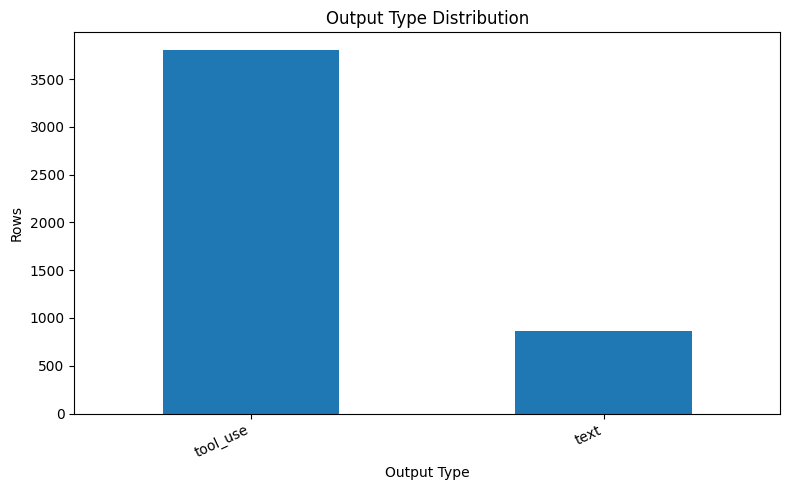

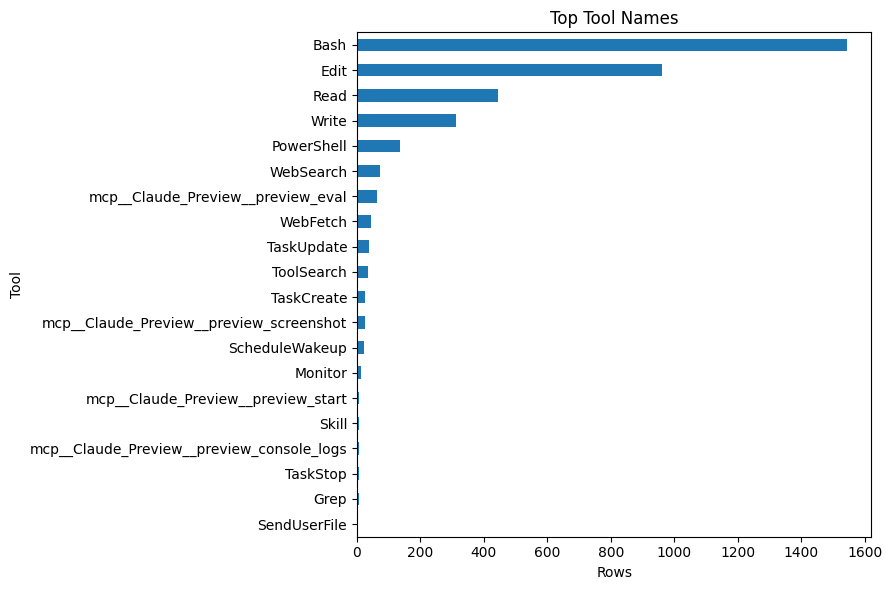

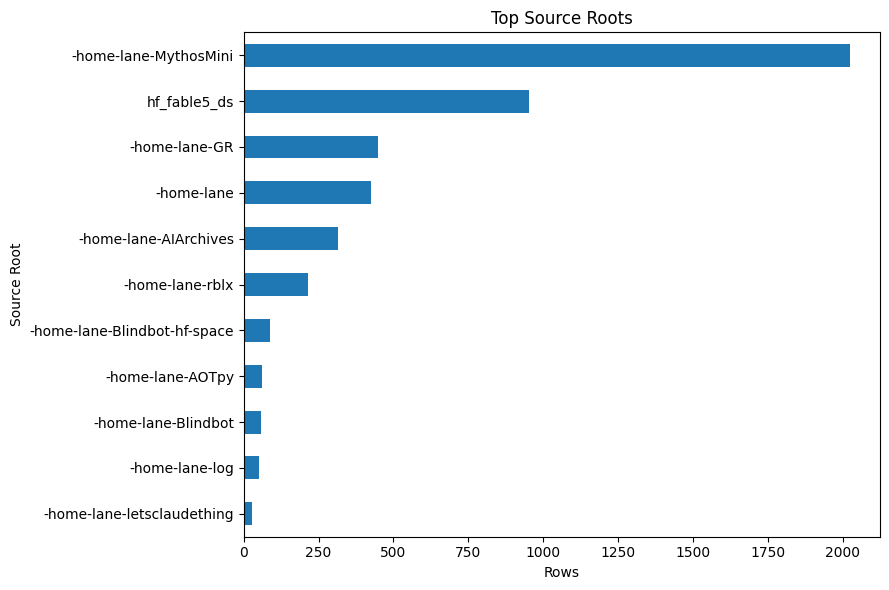

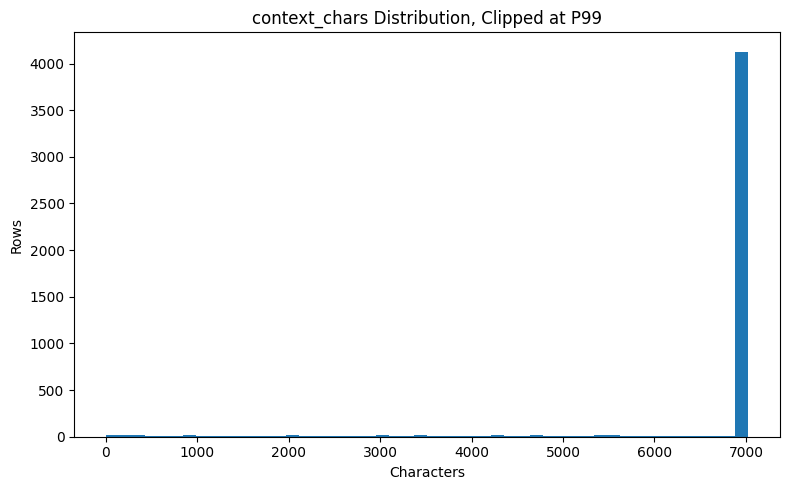

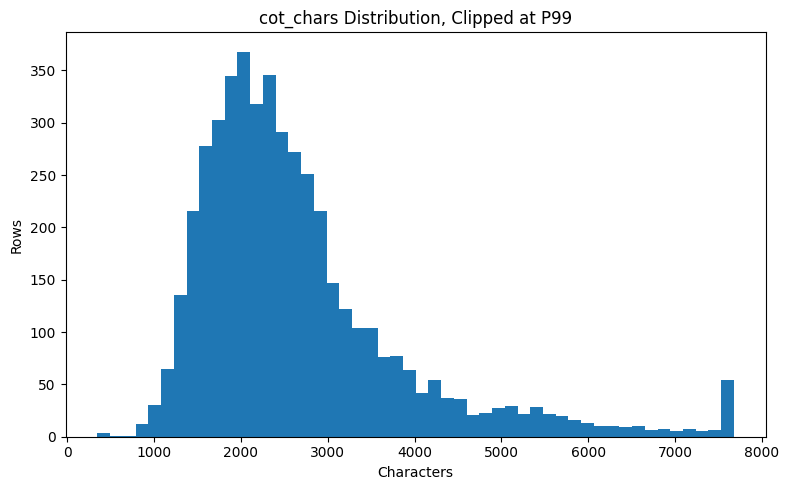

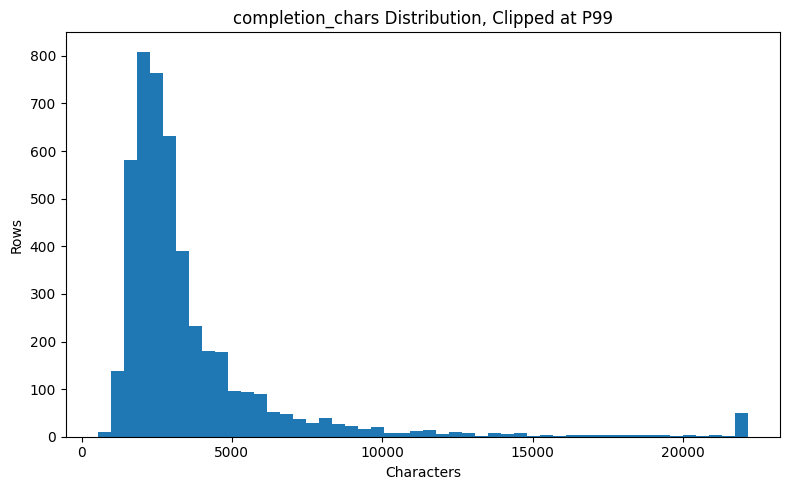

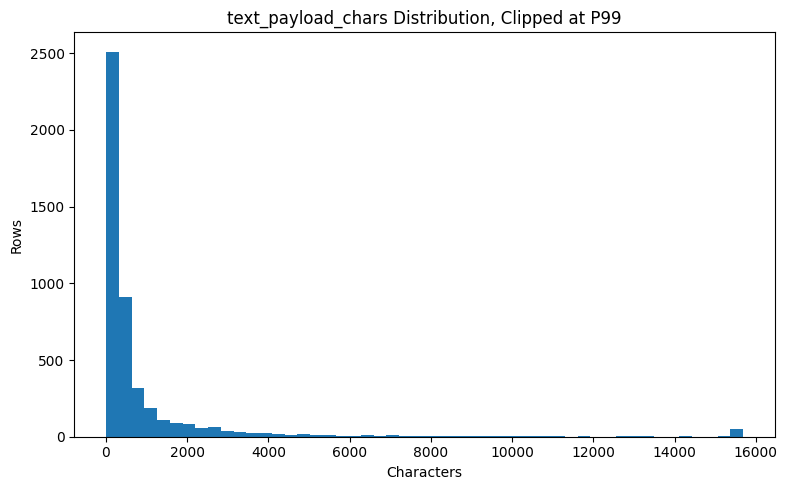

╭─────────────────────────────────────────────╮
│ Creating pure NumPy TF-IDF-style projection │
╰─────────────────────────────────────────────╯

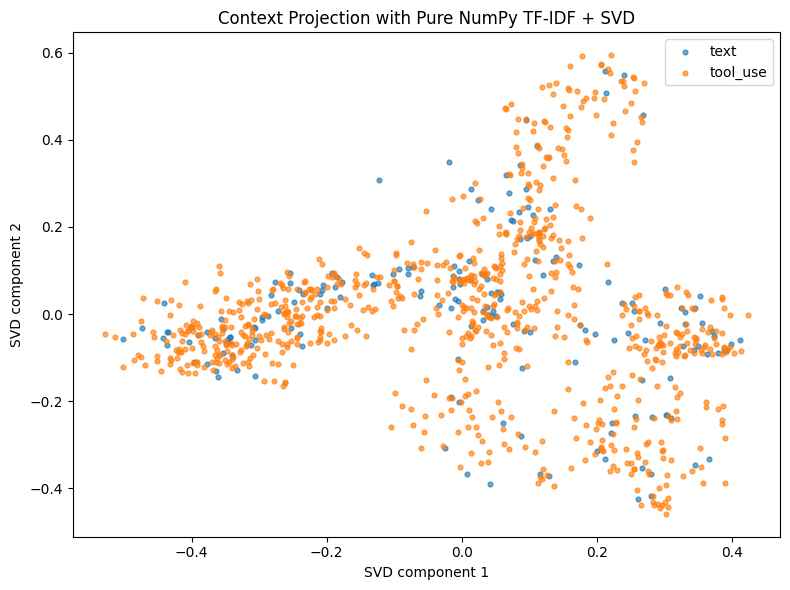

╭───────────────────────────────────────╮
│ Creating safe no-CoT chat/SFT exports │
╰───────────────────────────────────────╯

Saved train: 4198 records -> /content/fable5_traces_tutorial_outputs/fable5_no_cot_chat_train.jsonl

Saved validation: 233 records -> /content/fable5_traces_tutorial_outputs/fable5_no_cot_chat_validation.jsonl

Saved test: 234 records -> /content/fable5_traces_tutorial_outputs/fable5_no_cot_chat_test.jsonl

Skipped CoT-preserving export because SAVE_COT_RESEARCH_EXPORT=False.

...

╭───────────────────────────────────────╮
│ Building simple keyword search helper │
╰───────────────────────────────────────╯

Example keyword search results:

{
  "Bash": [
    {
      "uid": "f956721a-0af7-4bdc-8678-3a493d8fcd39#5",
      "session": "f956721a-0af7-4bdc-8678-3a493d8fcd39",
      "output_type": "tool_use",
      "tool_name": "Read",
      "context_preview": "USER: Make a new one, it should be a fast paced multiplayer FPS (with optinal bots) with 
full ray-traced stuff with lots of settings. TL;DR clone CSgo to the best of your ability. Look at the result and 
refine it USER: <local-command-caveat>Caveat: The messages below were generated by the user while running local 
commands. DO NOT respond to these messages or otherwise consider them in your respons ... ",
      "payload_preview": "{ \"tool\": \"Read\", \"input\": { \"file_path\": 
\"/home/lane/AIArchives/server/index.js\" } }"
    },
    {
      "uid": "f956721a-0af7-4bdc-8678-3a493d8fcd39#4",
      "session": "f956721a-0af7-4bdc-8678-3a493d8fcd39",
      "output_type": "tool_use",
      "tool_name": "Bash",
      "context_preview": "USER: Make a new one, it should be a fast paced multiplayer FPS (with optinal bots) with 
full ray-traced stuff with lots of settings. TL;DR clone CSgo to the best of your ability. Look at the result and 
refine it USER: <local-command-caveat>Caveat: The messages below were generated by the user while running local 
commands. DO NOT respond to these messages or otherwise consider them in your respons ... ",
      "payload_preview": "{ \"tool\": \"Bash\", \"input\": { \"command\": \"cat /home/lane/AIArchives/package.json;
echo ---; find /home/lane/AIArchives/archives /home/lane/AIArchives/public /home/lane/AIArchives/server -type f | 
grep -v node_modules | head -40\", \"description\": \"Inspect package.json and file tree\" } }"
    }
  ],
  "Write": [
    {
      "uid": "f956721a-0af7-4bdc-8678-3a493d8fcd39#10",
      "session": "f956721a-0af7-4bdc-8678-3a493d8fcd39",
      "output_type": "text",
      "tool_name": "",
      "context_preview": "…… -x--- 161 lane lane 20480 Jun 12 14:08 .. drwxrwxr-x 3 lane lane 4096 Jun 12 09:49 
archives drwxrwxr-x 86 lane lane 4096 Jun 12 09:52 node_modules -rw-rw-r-- 1 lane lane 287 Jun 12 09:52 
package.json -rw-rw-r-- 1 lane lane 37037 Jun 12 09:52 package-lock.json drwxrwxr-x 4 lane lane 4096 Jun 12 09:49 
public drwxrwxr-x 2 lane lane 4096 Jun 12 09:48 server ASSISTANT (tool call)  ... ",
      "payload_preview": "Renderer done. Now audio — pure-DSP SFX generators (testable arrays) + playback engine."
    },
    {
      "uid": "f956721a-0af7-4bdc-8678-3a493d8fcd39#15",
      "session": "f956721a-0af7-4bdc-8678-3a493d8fcd39",
      "output_type": "text",
      "tool_name": "",
      "context_preview": "…… atform — auth, avatars, multiplayer worlds, studio editor, real-time physics — 
generated in a single shot. Express backend, Three.js 3D rendering, WebSocket multiplayer. 4 pre-built official 
games, catalog system, friends, currencies.\", 8 \"description\": \"A complete Roblox-inspired sandbox platform 
built entirely from one prompt. Features include user registration and authenti ... ",
      "payload_preview": "Now HUD — viewmodel canvas, radar, killfeed, damage numbers, buy menu."
    }
  ],
  "browser": [
    {
      "uid": "f956721a-0af7-4bdc-8678-3a493d8fcd39#5",
      "session": "f956721a-0af7-4bdc-8678-3a493d8fcd39",
      "output_type": "tool_use",
      "tool_name": "Read",
      "context_preview": "USER: Make a new one, it should be a fast paced multiplayer FPS (with optinal bots) with 
full ray-traced stuff with lots of settings. TL;DR clone CSgo to the best of your ability. Look at the result and 
refine it USER: <local-command-caveat>Caveat: The messages below were generated by the user while running local 
commands. DO NOT respond to these messages or otherwise consider them in your respons ... ",
      "payload_preview": "{ \"tool\": \"Read\", \"input\": { \"file_path\": 
\"/home/lane/AIArchives/server/index.js\" } }"
    },
    {
      "uid": "f956721a-0af7-4bdc-8678-3a493d8fcd39#4",
      "session": "f956721a-0af7-4bdc-86

╭────────────────────────────────── Done ──────────────────────────────────╮
│ Tutorial complete.                                                       │
│                                                                          │
│ Artifacts saved in:                                                      │
│ /content/fable5_traces_tutorial_outputs                                  │
│                                                                          │
│ Key files:                                                               │
│ - /content/fable5_traces_tutorial_outputs/REPORT.md                      │
│ - /content/fable5_traces_tutorial_outputs/analysis_summary.json          │
│ - /content/fable5_traces_tutorial_outputs/fable5_no_cot_chat_train.jsonl │
│ - /content/fable5_traces_tutorial_outputs/fable5_analysis_index.csv      │
╰──────────────────────────────────────────────────────────────────────────╯

,artifact,path
0,Report,/content/fable5_traces_tutorial_outputs/REPORT.md
1,Summary JSON,/content/fable5_traces_tutorial_outputs/analys...
2,No-CoT train export,/content/fable5_traces_tutorial_outputs/fable5...
3,No-CoT validation export,/content/fable5_traces_tutorial_outputs/fable5...
4,No-CoT test export,/content/fable5_traces_tutorial_outputs/fable5...
5,Analysis CSV,/content/fable5_traces_tutorial_outputs/fable5...
6,Analysis pickle,/content/fable5_traces_tutorial_outputs/fable5...
7,Keyword search demo,/content/fable5_traces_tutorial_outputs/keywor...


In [5]:
rprint(Panel.fit("[bold]Baseline 1: Predict output_type from context using pure Python Naive Bayes[/bold]"))

model_artifacts = {}

classifier_df = df.dropna(subset=["output_type"]).copy()
classifier_df = classifier_df[
    classifier_df["output_type"].astype(str).str.len() > 0
].copy()

if classifier_df["output_type"].nunique() >= 2 and len(classifier_df) >= 30:
    X_text = (
        classifier_df["context"]
        .fillna("")
        .astype(str)
        .map(lambda text: text[:12000])
        .tolist()
    )

    y = classifier_df["output_type"].astype(str).tolist()

    train_indices, test_indices = stratified_train_test_indices(y, test_size=0.2, seed=SEED)

    X_train = [X_text[i] for i in train_indices]
    y_train = [y[i] for i in train_indices]
    X_test = [X_text[i] for i in test_indices]
    y_test = [y[i] for i in test_indices]

    output_type_classifier = PureMultinomialNB(
        max_features=20000,
        min_df=2,
        alpha=1.0,
    )

    output_type_classifier.fit(X_train, y_train)
    predictions = output_type_classifier.predict(X_test)

    output_type_metrics, output_report_df = evaluate_predictions(y_test, predictions)
    output_matrix_df = confusion_matrix_df(y_test, predictions)

    output_type_metrics["train_rows"] = len(X_train)
    output_type_metrics["test_rows"] = len(X_test)
    output_type_metrics["vocab_size"] = len(output_type_classifier.vocab)

    rprint("[bold]Output type classifier report:[/bold]")
    display(output_report_df)
    display(output_matrix_df)

    output_report_df.to_csv(OUT_DIR / "output_type_classifier_report.csv", index=False)
    output_matrix_df.to_csv(OUT_DIR / "output_type_confusion_matrix.csv")

    top_token_records = []

    for label in output_type_classifier.labels:
        for token, margin in output_type_classifier.top_tokens_for_class(label, n=25):
            top_token_records.append(
                {
                    "label": label,
                    "token": token,
                    "score_margin": margin,
                }
            )

    pd.DataFrame(top_token_records).to_csv(
        OUT_DIR / "output_type_top_tokens.csv",
        index=False,
    )

    with open(
        OUT_DIR / "output_type_classifier_metrics.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(output_type_metrics, file, ensure_ascii=False, indent=2)

    model_artifacts["output_type_classifier_metrics"] = str(
        OUT_DIR / "output_type_classifier_metrics.json"
    )

    model_artifacts["output_type_classifier_report"] = str(
        OUT_DIR / "output_type_classifier_report.csv"
    )

    model_artifacts["output_type_confusion_matrix"] = str(
        OUT_DIR / "output_type_confusion_matrix.csv"
    )

    model_artifacts["output_type_top_tokens"] = str(
        OUT_DIR / "output_type_top_tokens.csv"
    )

else:
    rprint(
        "[yellow]Skipping output_type classifier because there are too few "
        "classes or rows.[/yellow]"
    )

    output_type_metrics = {}

rprint(Panel.fit("[bold]Baseline 2: Predict tool_name from context using pure Python Naive Bayes[/bold]"))

tool_classifier_df = df[
    df["output_type"].eq("tool_use")
    & df["tool_name"].fillna("").astype(str).str.len().gt(0)
].copy()

if len(tool_classifier_df) >= 50 and tool_classifier_df["tool_name"].nunique() >= 2:
    top_tools = tool_classifier_df["tool_name"].value_counts().head(12).index.tolist()

    tool_classifier_df["tool_label"] = tool_classifier_df["tool_name"].where(
        tool_classifier_df["tool_name"].isin(top_tools),
        "__OTHER__",
    )

    y_tool = tool_classifier_df["tool_label"].astype(str).tolist()

    X_tool_text = (
        tool_classifier_df["context"]
        .fillna("")
        .astype(str)
        .map(lambda text: text[:12000])
        .tolist()
    )

    if len(set(y_tool)) >= 2:
        train_indices, test_indices = stratified_train_test_indices(y_tool, test_size=0.2, seed=SEED)

        X_train = [X_tool_text[i] for i in train_indices]
        y_train = [y_tool[i] for i in train_indices]
        X_test = [X_tool_text[i] for i in test_indices]
        y_test = [y_tool[i] for i in test_indices]

        tool_classifier = PureMultinomialNB(
            max_features=20000,
            min_df=2,
            alpha=1.0,
        )

        tool_classifier.fit(X_train, y_train)
        tool_predictions = tool_classifier.predict(X_test)

        tool_metrics, tool_report_df = evaluate_predictions(y_test, tool_predictions)
        tool_matrix_df = confusion_matrix_df(y_test, tool_predictions)

        tool_metrics["train_rows"] = len(X_train)
        tool_metrics["test_rows"] = len(X_test)
        tool_metrics["vocab_size"] = len(tool_classifier.vocab)

        rprint("[bold]Tool classifier report:[/bold]")
        display(tool_report_df)
        display(tool_matrix_df)

        tool_report_df.to_csv(OUT_DIR / "tool_name_classifier_report.csv", index=False)
        tool_matrix_df.to_csv(OUT_DIR / "tool_name_confusion_matrix.csv")

        top_tool_token_records = []

        for label in tool_classifier.labels:
            for token, margin in tool_classifier.top_tokens_for_class(label, n=25):
                top_tool_token_records.append(
                    {
                        "label": label,
                        "token": token,
                        "score_margin": margin,
                    }
                )

        pd.DataFrame(top_tool_token_records).to_csv(
            OUT_DIR / "tool_name_top_tokens.csv",
            index=False,
        )

        with open(
            OUT_DIR / "tool_name_classifier_metrics.json",
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(tool_metrics, file, ensure_ascii=False, indent=2)

        model_artifacts["tool_name_classifier_metrics"] = str(
            OUT_DIR / "tool_name_classifier_metrics.json"
        )

        model_artifacts["tool_name_classifier_report"] = str(
            OUT_DIR / "tool_name_classifier_report.csv"
        )

        model_artifacts["tool_name_confusion_matrix"] = str(
            OUT_DIR / "tool_name_confusion_matrix.csv"
        )

        model_artifacts["tool_name_top_tokens"] = str(
            OUT_DIR / "tool_name_top_tokens.csv"
        )

    else:
        rprint("[yellow]Skipping tool classifier because labels collapsed to one class.[/yellow]")
        tool_metrics = {}

else:
    rprint(
        "[yellow]Skipping tool classifier because there are too few tool-use "
        "rows or tool classes.[/yellow]"
    )

    tool_metrics = {}

rprint(Panel.fit("[bold]Building simple keyword search helper[/bold]"))

def search_rows(keyword, limit=5, search_cols=("context", "cot", "completion", "text_payload")):
    keyword = str(keyword).lower()
    mask = pd.Series(False, index=df.index)

    for column in search_cols:
        mask = mask | (
            df[column]
            .fillna("")
            .astype(str)
            .str.lower()
            .str.contains(re.escape(keyword), regex=True)
        )

    hits = df[mask].head(limit)
    results = []

    for _, row in hits.iterrows():
        results.append(
            {
                "uid": row.get("uid"),
                "session": row.get("session"),
                "output_type": row.get("output_type"),
                "tool_name": row.get("tool_name"),
                "context_preview": preview_text(row.get("context"), 400),
                "payload_preview": preview_text(row.get("text_payload"), 400),
            }
        )

    return results

example_queries = [
    "Bash",
    "Write",
    "browser",
    "test",
    "README",
]

search_demo = {
    query: search_rows(query, limit=2)
    for query in example_queries
}

with open(
    OUT_DIR / "keyword_search_demo.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(search_demo, file, ensure_ascii=False, indent=2)

rprint("[bold]Example keyword search results:[/bold]")
rprint(safe_json_dumps(search_demo, max_chars=5000))

summary = {
    "dataset_id": DATASET_ID,
    "flat_jsonl_filename": FLAT_JSONL_FILENAME,
    "output_directory": str(OUT_DIR),
    "repo_file_summary": file_summary,
    "rows": int(len(df)),
    "columns": list(df.columns),
    "output_type_distribution": (
        df["output_type"]
        .fillna("missing")
        .value_counts()
        .to_dict()
    ),
    "top_tools": (
        df.loc[df["output_type"].eq("tool_use"), "tool_name"]
        .replace("", "unknown")
        .value_counts()
        .head(20)
        .to_dict()
    ),
    "top_source_roots": (
        df["source_root"]
        .fillna("unknown")
        .value_counts()
        .head(20)
        .to_dict()
    ),
    "length_summary": {
        column: {
            "mean": float(df[column].mean()),
            "median": float(df[column].median()),
            "p90": float(df[column].quantile(0.90)),
            "p95": float(df[column].quantile(0.95)),
            "max": int(df[column].max()),
        }
        for column in [
            "context_chars",
            "cot_chars",
            "completion_chars",
            "text_payload_chars",
        ]
    },
    "possible_secret_rows": int(df["possible_secret_anywhere"].sum()),
    "plots": plot_paths,
    "model_artifacts": model_artifacts,
    "safe_exports": {
        "train": str(OUT_DIR / "fable5_no_cot_chat_train.jsonl"),
        "validation": str(OUT_DIR / "fable5_no_cot_chat_validation.jsonl"),
        "test": str(OUT_DIR / "fable5_no_cot_chat_test.jsonl"),
    },
    "analysis_files": {
        "csv": str(OUT_DIR / "fable5_analysis_index.csv"),
        "pickle": str(OUT_DIR / "fable5_analysis_index.pkl"),
        "keyword_search_demo": str(OUT_DIR / "keyword_search_demo.json"),
    },
}

with open(
    OUT_DIR / "analysis_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(clean_for_json(summary), file, ensure_ascii=False, indent=2, default=str)

FENCE = chr(96) * 3

report_md = (
    "# Fable 5 Traces Advanced Tutorial Report\n\n"
    "## Dataset\n\n"
    f"- Dataset: `{DATASET_ID}`\n"
    f"- Flat JSONL: `{FLAT_JSONL_FILENAME}`\n"
    f"- Rows loaded: `{len(df):,}`\n"
    f"- Unique source sessions: `{df['session'].nunique(dropna=True):,}`\n"
    f"- Unique models: `{df['model'].nunique(dropna=True):,}`\n\n"
    "## Important safety note\n\n"
    "This tutorial treats the dataset as agent telemetry. It previews and analyzes commands, "
    "tool calls, file edits, and transcript text, but it never executes commands found inside "
    "the traces.\n\n"
    f"Potential secret-like patterns detected: `{int(df['possible_secret_anywhere'].sum()):,}` rows.\n"
    "Exports redact common API-key/token-like patterns.\n\n"
    "## Output type distribution\n\n"
    f"{FENCE}json\n"
    f"{json.dumps(clean_for_json(summary['output_type_distribution']), indent=2, ensure_ascii=False)}\n"
    f"{FENCE}\n\n"
    "## Top tools\n\n"
    f"{FENCE}json\n"
    f"{json.dumps(clean_for_json(summary['top_tools']), indent=2, ensure_ascii=False)}\n"
    f"{FENCE}\n\n"
    "## Saved files\n\n"
    "- `analysis_summary.json`\n"
    "- `fable5_analysis_index.csv`\n"
    "- `fable5_analysis_index.pkl`\n"
    "- `fable5_no_cot_chat_train.jsonl`\n"
    "- `fable5_no_cot_chat_validation.jsonl`\n"
    "- `fable5_no_cot_chat_test.jsonl`\n"
    "- plot PNG files\n"
    "- baseline classifier metrics, when enough rows/classes are available\n\n"
    "## Recommended next steps\n\n"
    "1. Inspect `fable5_no_cot_chat_train.jsonl` before any fine-tuning.\n"
    "2. Keep the dataset license in mind before model training or redistribution.\n"
    "3. Avoid training directly on raw terminal outputs without additional privacy and safety filtering.\n"
    "4. Start with the no-CoT chat export unless your research explicitly requires reasoning-trace supervision.\n"
)

with open(
    OUT_DIR / "REPORT.md",
    "w",
    encoding="utf-8",
) as file:
    file.write(report_md)

rprint(
    Panel.fit(
        f"[bold green]Tutorial complete.[/bold green]\n\n"
        f"Artifacts saved in:\n{OUT_DIR}\n\n"
        f"Key files:\n"
        f"- {OUT_DIR / 'REPORT.md'}\n"
        f"- {OUT_DIR / 'analysis_summary.json'}\n"
        f"- {OUT_DIR / 'fable5_no_cot_chat_train.jsonl'}\n"
        f"- {OUT_DIR / 'fable5_analysis_index.csv'}",
        title="Done",
    )
)

display(
    pd.DataFrame(
        {
            "artifact": [
                "Report",
                "Summary JSON",
                "No-CoT train export",
                "No-CoT validation export",
                "No-CoT test export",
                "Analysis CSV",
                "Analysis pickle",
                "Keyword search demo",
            ],
            "path": [
                str(OUT_DIR / "REPORT.md"),
                str(OUT_DIR / "analysis_summary.json"),
                str(OUT_DIR / "fable5_no_cot_chat_train.jsonl"),
                str(OUT_DIR / "fable5_no_cot_chat_validation.jsonl"),
                str(OUT_DIR / "fable5_no_cot_chat_test.jsonl"),
                str(OUT_DIR / "fable5_analysis_index.csv"),
                str(OUT_DIR / "fable5_analysis_index.pkl"),
                str(OUT_DIR / "keyword_search_demo.json"),
            ],
        }
    )
)